<a href="https://colab.research.google.com/github/LP46-THX/Taller-Negocios-/blob/main/Taller2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import pandas as pd
import numpy as np

# Generar datos simulados
data = {
    'ID_Transaccion': range(1001, 1051),
    'Canal': np.random.choice(['Web Desktop', 'App Móvil'], 50, p=[0.4, 0.6]),
    'Metodo_Pago': np.random.choice(['Tarjeta Crédito', 'PayPal', 'Transferencia'], 50),
    'Total_Venta': np.random.randint(20, 500, 50), # Ventas entre $20 y $500
    'Categoria': np.random.choice(['Electrónica', 'Moda', 'Hogar'], 50)
}

df = pd.DataFrame(data)

df

,ID_Transaccion,Canal,Metodo_Pago,Total_Venta,Categoria
0,1001,Web Desktop,Tarjeta Crédito,67,Moda
1,1002,App Móvil,Tarjeta Crédito,372,Moda
2,1003,App Móvil,Tarjeta Crédito,295,Electrónica
3,1004,App Móvil,PayPal,175,Moda
4,1005,Web Desktop,Transferencia,76,Moda
5,1006,Web Desktop,Tarjeta Crédito,308,Moda
6,1007,Web Desktop,PayPal,133,Hogar
7,1008,App Móvil,PayPal,152,Electrónica
8,1009,App Móvil,PayPal,324,Hogar
9,1010,Web Desktop,PayPal,252,Electrónica


Es importante conocer la diferencia entre las ventas de la App movil y de la pagina WEB , asi que los KPI deberian responder a las preguntas de : 1.¿ Cuantas transacciones tiene cada uno de los modelos ? . 2  ¿ CUal es el ingreso promedio de consumo (ticket ) de cada uno de los modelos ?. 3 ¿ Cuales son los ingresos totales que aportan cada modelo a la empresa ? , 4 ¿ Cual es la forma de pago preferida por los usuarios en los diferentes modelos ?


In [42]:
df.groupby('Canal')['ID_Transaccion'].count()


,ID_Transaccion
Canal,
App Móvil,32
Web Desktop,18


In [43]:
df.groupby('Canal')['Total_Venta'].mean()


,Total_Venta
Canal,
App Móvil,234.968750
Web Desktop,243.055556


In [44]:
df.groupby('Canal')['Total_Venta'].sum()


,Total_Venta
Canal,
App Móvil,7519
Web Desktop,4375


In [45]:
df.groupby(['Canal','Metodo_Pago'])['ID_Transaccion'].count().unstack()


Metodo_Pago,PayPal,Tarjeta Crédito,Transferencia
Canal,,,
App Móvil,9,10,13
Web Desktop,12,5,1


Analisis de KPIs

El primer KPI muestra la preferencia de los usuarios al comprar productos de la empresa en este caso , la comodidad de la APP movil es mucho mas aceptada que la pagina WEB.

En el segundo KPI muestra los ingresos promedios de compras totales de cada modelo, la gente considera  que los dos modelos de compra son seguros para compras grnades.

 El tercer KPI muestra La cantidad de ingresos totales de cada modelo, en este caso la gente prefiere hacer compras en masa en la App movil ya que la consideran rapida y eficiente.

 En el cuarto KPI muestra la forma de pago recurrente en los dos modelos , para la APP movil una trasferencia directa es la mas comoda de utilizar mientras que en la WEB, utiliza un canal externo (paypal) que facilita los pagos y mantiene el dinero de las cuentas seguro.



In [46]:
import pandas as pd

data = pd.read_csv('Train.csv')
data



,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0


1. KPIs de Gestión de Logística y Operaciones (Shipment & Warehouse)
Permiten medir la eficiencia en la distribución de los productos electrónicos.

1.1. Costo Promedio de Envío por Modo de Transporte (Mode of Shipment): Ayuda a evaluar qué canales (Barco, Avión, Carretera) representan un mayor impacto financiero en relación con el peso del producto.

1.2. Volumen de Ocupación por Bloque de Bodega (Warehouse Block): Porcentaje o cantidad total de productos/peso administrados en cada bloque (A, B, C, D, E) para entender la carga operativa de la infraestructura.

1.3. Peso Promedio del Producto por Modo de Envío: Para analizar si se está optimizando la logística (ej. si los productos más pesados se están enviando por barco o si se está gastando de más enviándolos por avión).

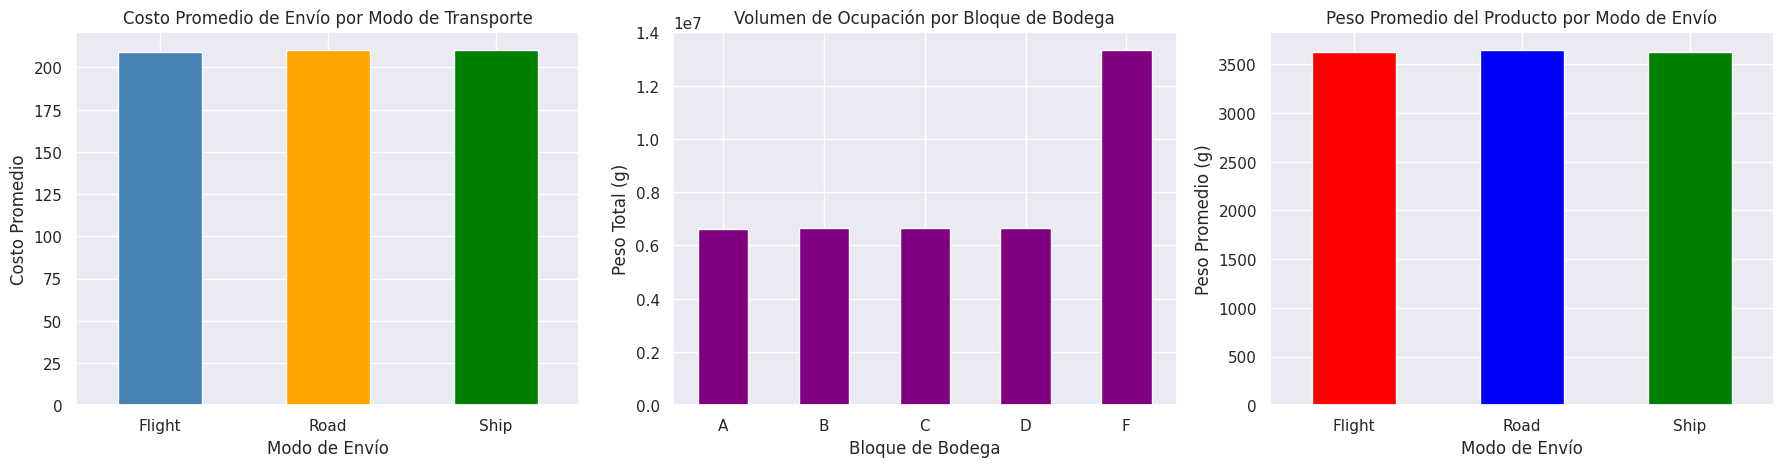

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('Train.csv')

sns.set_theme()
fig, axes = plt.subplots(1, 3, figsize=(18,5))  # 1 fila, 3 columnas

# 1️⃣ Costo Promedio de Envío por Modo de Transporte
costo_promedio = data.groupby('Mode_of_Shipment')['Cost_of_the_Product'].mean()
costo_promedio.plot(kind='bar', color=['steelblue','orange','green'], ax=axes[0])
axes[0].set_title('Costo Promedio de Envío por Modo de Transporte')
axes[0].set_ylabel('Costo Promedio')
axes[0].set_xlabel('Modo de Envío')
axes[0].tick_params(axis='x', rotation=0)

# 2️⃣ Volumen de Ocupación por Bloque de Bodega
volumen_bodega = data.groupby('Warehouse_block')['Weight_in_gms'].sum()
volumen_bodega.plot(kind='bar', color='purple', ax=axes[1])
axes[1].set_title('Volumen de Ocupación por Bloque de Bodega')
axes[1].set_ylabel('Peso Total (g)')
axes[1].set_xlabel('Bloque de Bodega')
axes[1].tick_params(axis='x', rotation=0)

# 3️⃣ Peso Promedio del Producto por Modo de Envío
peso_promedio = data.groupby('Mode_of_Shipment')['Weight_in_gms'].mean()
peso_promedio.plot(kind='bar', color=['red','blue','green'], ax=axes[2])
axes[2].set_title('Peso Promedio del Producto por Modo de Envío')
axes[2].set_ylabel('Peso Promedio (g)')
axes[2].set_xlabel('Modo de Envío')
axes[2].tick_params(axis='x', rotation=0)

# Ajustar espacios
plt.tight_layout()
plt.show()



 KPI 1: Costo Promedio de Envío por Modo de Transporte
 Si el costo promedio es más alto en envíos por avión, puede indicar que se están destinando productos de mayor valor a este canal, lo cual incrementa el riesgo financiero si no se justifica por rapidez o urgencia. En cambio, un costo más bajo en carretera o barco puede reflejar que se usan para productos más económicos o de menor prioridad.


 KPI 2: Volumen de Ocupación por Bloque de Bodega
 Si un bloque concentra demasiado volumen, puede haber riesgo de saturación y cuellos de botella operativos. Una distribución más equilibrada facilita la gestión y reduce errores.


KPI 3: Peso Promedio del Producto por Modo de Envío

 Si los productos más pesados se envían por avión, la logística puede estar siendo ineficiente, ya que el avión es el modo más costoso. Lo ideal es que los productos más pesados se envíen por barco o carretera, reservando el avión para productos ligeros y urgentes.





In [67]:
import pandas as pd

# KPI 1: Ingreso Total Bruto y Costo Promedio del Producto
ingreso_total = data['Cost_of_the_Product'].sum()
costo_promedio = data['Cost_of_the_Product'].mean()

tabla_kpi1 = pd.DataFrame({
    'Indicador': ['Ingreso Total Bruto', 'Costo Promedio del Producto'],
    'Valor': [ingreso_total, costo_promedio]
})
# Convert 'Valor' column to integer type for display
tabla_kpi1['Valor'] = tabla_kpi1['Valor'].astype(int)
print("KPI 1: Ingreso Total Bruto y Ticket Promedio")
display(tabla_kpi1)

# KPI 2: Porcentaje de Descuento Promedio Otorgado
descuento_promedio = data['Discount_offered'].mean()

tabla_kpi2 = pd.DataFrame({
    'Indicador': ['Descuento Promedio (%)'],
    'Valor': [descuento_promedio]
})
print("KPI 2: Descuento Promedio Otorgado")
display(tabla_kpi2)

KPI 1: Ingreso Total Bruto y Ticket Promedio


,Indicador,Valor
0,Ingreso Total Bruto,2311955
1,Costo Promedio del Producto,210


KPI 2: Descuento Promedio Otorgado


,Indicador,Valor
0,Descuento Promedio (%),13.373216


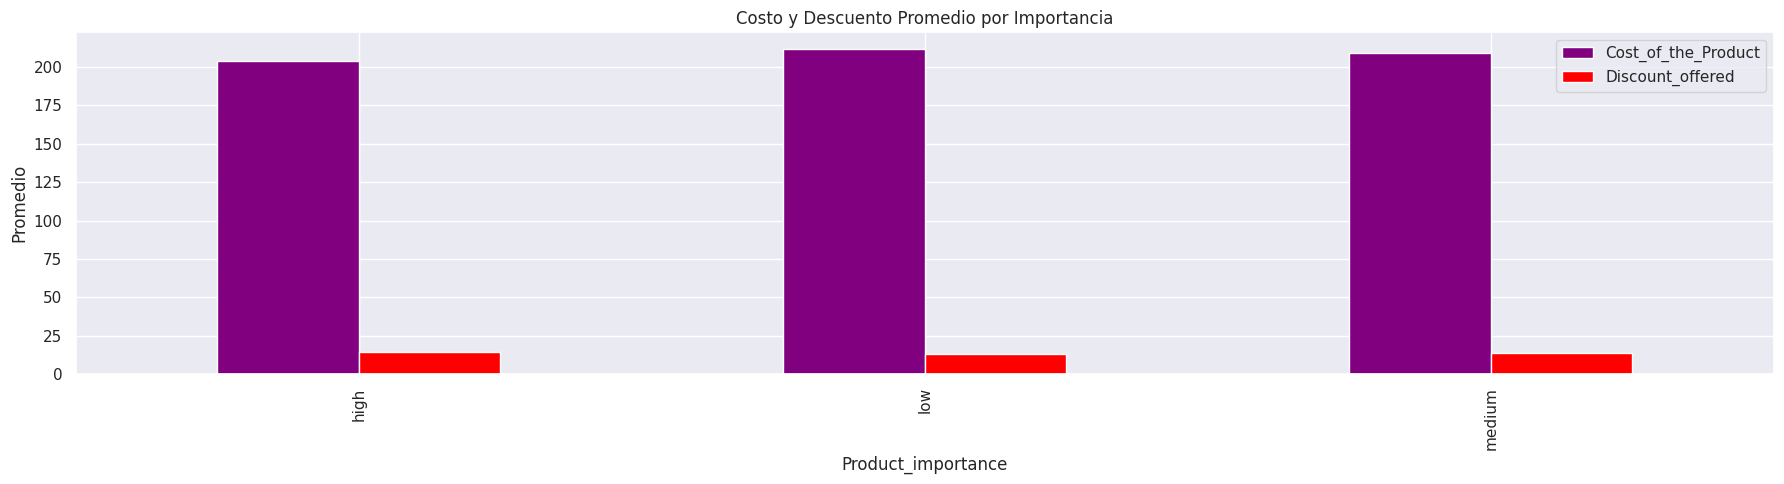

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
fig, axes = plt.subplots(1, 1, figsize=(18,5))  # Creates a single subplot

# 3️ Margen Teórico Relativo por Importancia del Producto
margen_importancia = data.groupby('Product_importance').agg({
    'Cost_of_the_Product':'mean',
    'Discount_offered':'mean'
})
margen_importancia.plot(kind='bar', ax=axes, color=['purple','red']) # Use 'axes' directly
axes.set_title('Costo y Descuento Promedio por Importancia') # Use 'axes' directly
axes.set_ylabel('Promedio') # Use 'axes' directly

plt.tight_layout()
plt.show()

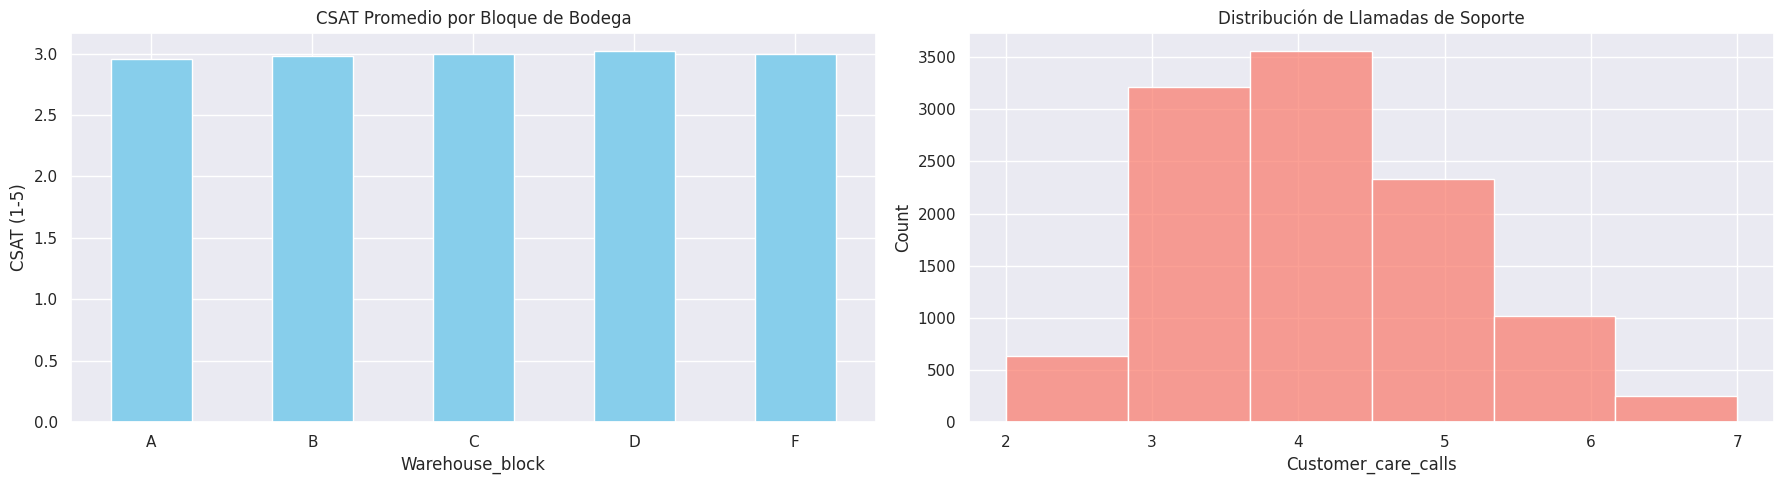

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(18,5))  # 1 fila, 3 columnas

# 4️ Índice de Satisfacción del Cliente (CSAT)
csat_bodega = data.groupby('Warehouse_block')['Customer_rating'].mean()
csat_bodega.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('CSAT Promedio por Bloque de Bodega')
axes[0].set_ylabel('CSAT (1-5)')
axes[0].tick_params(axis='x', rotation=0)





# Carga de Soporte: Histograma ajustado
sns.histplot(data['Customer_care_calls'], kde=False, ax=axes[1], color='salmon', bins=6)
axes[1].set_title('Distribución de Llamadas de Soporte')



plt.tight_layout()
plt.show()


In [65]:
# KPI 5: Tasa de Retención / Clientes Recurrentes
data['Tipo_Cliente'] = data['Prior_purchases'].apply(lambda x: 'Nuevo' if x <= 1 else 'Recurrente')
retencion = data['Tipo_Cliente'].value_counts(normalize=True) * 100

tabla_kpi5 = pd.DataFrame({
    'Tipo de Cliente': retencion.index,
    'Porcentaje (%)': retencion.values
})
print("KPI 5: Distribución de Clientes")
display(tabla_kpi5)

KPI 5: Distribución de Clientes


,Tipo de Cliente,Porcentaje (%)
0,Recurrente,100.0


Analisis de datos
KPI 1: Ingreso Total Bruto y Costo Promedio del Producto
 El ingreso total bruto refleja el volumen económico que genera la tienda, mientras que el costo promedio del producto nos da una idea del ticket medio de compra.


 KPI 2: Porcentaje de Descuento Promedio Otorgado
 Este indicador mide la intensidad de las promociones. Un descuento promedio elevado puede atraer clientes, pero también reduce el margen.


 KPI 3: Margen Teórico Relativo por Importancia del Producto
 Al cruzar la importancia del producto (Low, Medium, High) con su costo y descuento, se observa si los productos considerados estratégicos realmente son los más caros o si reciben más promociones.

KPI 4: Índice de Satisfacción del Cliente (CSAT)
 El CSAT promedio muestra el nivel general de satisfacción. Segmentarlo por género o bloque de bodega permite detectar anomalías operativas o de servicio.

 KPI 5: Tasa de Retención / Clientes Recurrentes
Este KPI mide la fidelización. Clientes con 0–1 compras previas son nuevos, mientras que 2 o más indican recurrencia.

 KPI 6: Carga de Soporte por Cliente (Customer Care Calls)
 El promedio de llamadas de soporte indica el nivel de fricción en la experiencia del cliente. Relacionarlo con costo del producto y rating permite ver patrones en como actuan los clientes por llamadas .

